## 7장 로지스틱 회귀

### 1. 럭키백의 확률

1.1 데이터 준비하기

In [1]:
# 로컬 디스크 데이터를 가져오기 위해 google.colab에서 files라는 package를 import한다.
from google.colab import files
import io
import pandas as pd
import numpy as np

# files.upload()에 의해 [파일 선택] 버튼이 생성된다.
uploaded = files.upload()

Saving fish.csv to fish.csv


In [2]:
# read_csv()으로 업로드된 파일을 Byte단위로 읽어서 데이터프레임을 생성한다.
fish = pd.read_csv(io.BytesIO(uploaded['fish.csv']))

# fish 데이터프레임의 기본 정보를 확인한다.
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


In [3]:
# fish 데이터프레임의 상위 5개의 데이터를 확인한다.
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
# 어떤 종류의 생선이 있는지 Species열에서 고유한 값을 추출한다.
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


1.2 입력데이터와 정답데이터 만들기
*   Species열을 타깃(정답)으로 만들고, 나머지 5개 열은 입력 데이터로 사용한다.


In [6]:
# Species열을 제외한 5개의 열을 입력데이터로써 넘파이 배열을 만든다.
# to_numpy()은 데이터프레임을 넘파이 배열로 변환한다.
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()

In [7]:
# 배열에서 처음 5개의 행을 출력한다.
print(fish_input[:5])

[[242.      25.4     30.      11.52     4.02  ]
 [290.      26.3     31.2     12.48     4.3056]
 [340.      26.5     31.1     12.3778   4.6961]
 [363.      29.      33.5     12.73     4.4555]
 [430.      29.      34.      12.444    5.134 ]]


In [8]:
# Species열도 정답데이터로써 넘파이 배열로 만든다.
fish_target = fish['Species'].to_numpy()

1.3 훈련세트와 테스트세트 만들기

In [9]:
# 사이킷런의 train_test_split()로 훈련세트와 테스트세트를 만든다.
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

1.4 표준화 전처리

In [10]:
# StandardScaler클래스를 이용해서 표준화 전처리를 수행한다.
from sklearn.preprocessing import StandardScaler

# 객체 모델을 만들고 훈련시킨다.
ss = StandardScaler()
ss.fit(train_input)

# 훈련세트의 통계값으로 테스트세트를 변환해야한다.
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

### 2. k-최근접 이웃 분류 모델의 확률 예측

2.1 모델 객체를 생성하고 훈련과 평가를 한다.

In [11]:
# k-최근접 이웃 분류 클래스를 임포트한다.
from sklearn.neighbors import KNeighborsClassifier

# 최근접 이웃 개수를 3으로 지정하여 모델 객체를 만든다.
kn = KNeighborsClassifier(n_neighbors=3)

# 전처리된 훈련세트로 모델을 훈련시킨다.
kn.fit(train_scaled, train_target)

# 훈련세트와 테스트세트를 평가한다.
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


2.2 타깃값의 종류(7개)들을 확인하고, 타깃값을 예측해본다.

In [13]:
# KNeighborsClassifier에서 정렬된 타깃값은 classes_ 속성에 저장되어 있다.
# 순서가 자동으로 알파벳순으로 매겨진다.
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [14]:
# predit()는 타깃값으로 예측을 출력한다.
# 테스트 세트에 있는 처음 5개의 샘플의 타깃값을 예측해본다.
print(kn.predict(test_scaled[:5]))

['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']


2.3 샘플 5개에 대한 예측은 어떤 확률로 만들어졌을까?

In [15]:
import numpy as np
# 사이킷런의 분류모델은 predict_proba()로 클래스별 확률값을 반환한다.
proba = kn.predict_proba(test_scaled[:5])

# decimlas=4은 반올림해서 소숫점 4번째자리까지 표시한다.
print(np.round(proba, decimals=4))

[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [16]:
# 인덱스 3번째 샘플의 최근접 이웃의 클래스를 확인해본다.
# n_neighbors=3 으로 모델을 생성했으므로 이웃의 수는 3개이다.
distances, indexes = kn.kneighbors(test_scaled[3:4])
print(train_target[indexes])

[['Roach' 'Perch' 'Perch']]


### 3. 로지스틱 회귀

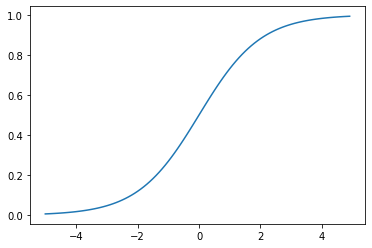

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -5와 5 사이에 0.1 간격으로 배열 z를 만든다.
z = np.arange(-5, 5, 0.1)

# z 위치마다 시그모이드 함수를 계산한다.
# 지수함수 계산은 np.exp()를 사용한다.
phi = 1 / (1 + np.exp(-z))

plt.plot(z, phi)
plt.show()

### 4. 로지스틱 회귀로 이진 분류 수행하기

4.1 도미와 빙어 데이터만 골라낸다.

In [19]:
# [기초] 불리언 인덱싱(boolean indexing)
# 넘파이 배열은 True, False 값을 전달하여 행을 선택할 수 있다.
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])

['A' 'C']


In [26]:
# train_target 배열에서 도미(Bream)와 빙어(Smelt)일 경우 True,
# 나머지는 False 값이 반환되어 bream_smelt_indexes 배열이 만들어진다.
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')

# bream_smelt_indexes 배열을 이용해서 훈련세트에서 도미와 빙어 데이터만 골라낸다.
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_semlt_indexes]

4.2 로지스틱 회귀 모델을 훈련시킨다.

In [27]:
# 사이킷런에서 로지스틱회귀 클래스를 임포트한다.
from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀모델 객체를 만들고 훈련시킨다.
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

4.3 샘플을 예측하고 예측 확률을 확인한다.

In [28]:
# 훈련한 모델을 사용해 train_bream_smelt에 있는 5개의 샘플을 예측해본다.
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [29]:
# predict_proba()은 예측 확률을 제공한다.
# 첫번째 열이 음성클래스(0)에 대한 확률이고, 두번째 열이 양성클래스(1)에 대한 확률이다.
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99759855 0.00240145]
 [0.02735183 0.97264817]
 [0.99486072 0.00513928]
 [0.98584202 0.01415798]
 [0.99767269 0.00232731]]


In [30]:
# 사이킷런은 타깃값을 알파벳순으로 정렬하여 사용한다.
# 음성클래스(0)는 도미(Bream)이고, 양성클래스(1)는 빙어(Smelt)이다.
print(lr.classes_)

['Bream' 'Smelt']


4.4 로지스틱 회귀 계수를 확인하고, 학습한 방정식을 구한다.

In [31]:
# 로지스틱 회귀가 학습한 계수를 확인해 본다.
print(lr.coef_, lr.intercept_)

[[-0.4037798  -0.57620209 -0.66280298 -1.01290277 -0.73168947]] [-2.16155132]


In [32]:
# decision_function()으로 z값을 출력할 수 있다.
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)

[-6.02927744  3.57123907 -5.26568906 -4.24321775 -6.0607117 ]


In [33]:
# z값을 시그모이드 함수에 통과시키면 확률을 얻을 수 있다.
# 파이썬의 사이파이(scipy)라이브러리에 시그모이드함수가 있다.
from scipy.special import expit

# decisions 배열의 값을 확률로 변환해본다.
# 출력된 값을 보면 predict_proba() 출력의 두번째 열의 값(양성클래스:1)과 동일하다.
# 즉, decision_function()은 양성 클래스에 대한 z값을 반환한다.
print(expit(decisions))

[0.00240145 0.97264817 0.00513928 0.01415798 0.00232731]
